In [29]:
from sklearn.datasets import load_digits
digits=load_digits()


In [30]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [31]:
digits.data.shape

(1797, 64)

In [32]:
digits.images.shape

(1797, 8, 8)

0


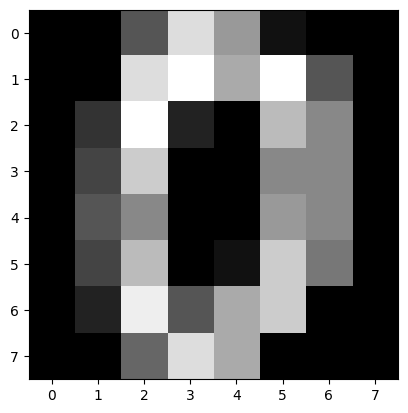

In [33]:
import matplotlib.pyplot as plt
x=digits.images[0]
print(digits.target[0])
plt.gray()
plt.imshow(x)
plt.show()
from sklearn.model_selection import train_test_split


# Preprocess 

In [34]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3)



In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Performance

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
def evaluate_model(y_train, y_test, y_train_pred, y_test_pred):
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
    print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))
    print("Train Recall:", recall_score(y_train, y_train_pred, average='weighted'))
    print("Test Recall:", recall_score(y_test, y_test_pred, average='weighted'))


## Classification

## 1. Random forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=120, n_estimators=256)
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)


Train Accuracy: 1.0
Test Accuracy: 0.975925925925926
Train Precision: 1.0
Test Precision: 0.9764689436078324
Train Recall: 1.0
Test Recall: 0.975925925925926


## 2. SVM

In [45]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

Train Accuracy: 0.9968178202068417
Test Accuracy: 0.987037037037037
Train Precision: 0.9968434122508549
Test Precision: 0.9871464540448389
Train Recall: 0.9968178202068417
Test Recall: 0.987037037037037


## 3. ANN 

In [51]:
from sklearn.neural_network  import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=1260 ,batch_size=10, max_iter=200,learning_rate='adaptive' )
mlp.fit(X_train, y_train)
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

Train Accuracy: 1.0
Test Accuracy: 0.9888888888888889
Train Precision: 1.0
Test Precision: 0.9889268664971091
Train Recall: 1.0
Test Recall: 0.9888888888888889


## 4. KNN

In [54]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2)
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3)
knn.fit(X_train, y_train)
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

Train Accuracy: 0.9920445505171042
Test Accuracy: 0.9888888888888889
Train Precision: 0.9921643581657007
Test Precision: 0.9898462021343377
Train Recall: 0.9920445505171042
Test Recall: 0.9888888888888889


# Compare 

              accuracy  precision    recall
model                                      
RandomForest  0.829630   0.882368  0.829630
SVM           0.083333   0.006944  0.083333
MLP           0.996296   0.996372  0.996296
KNN           0.988889   0.989846  0.988889


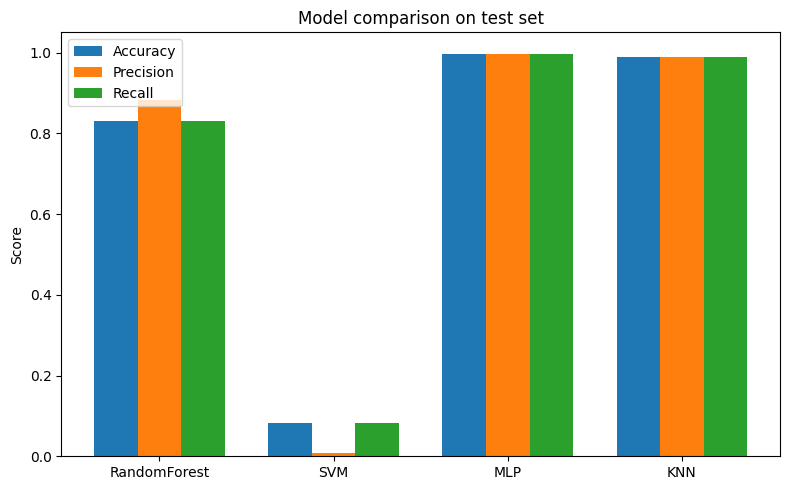

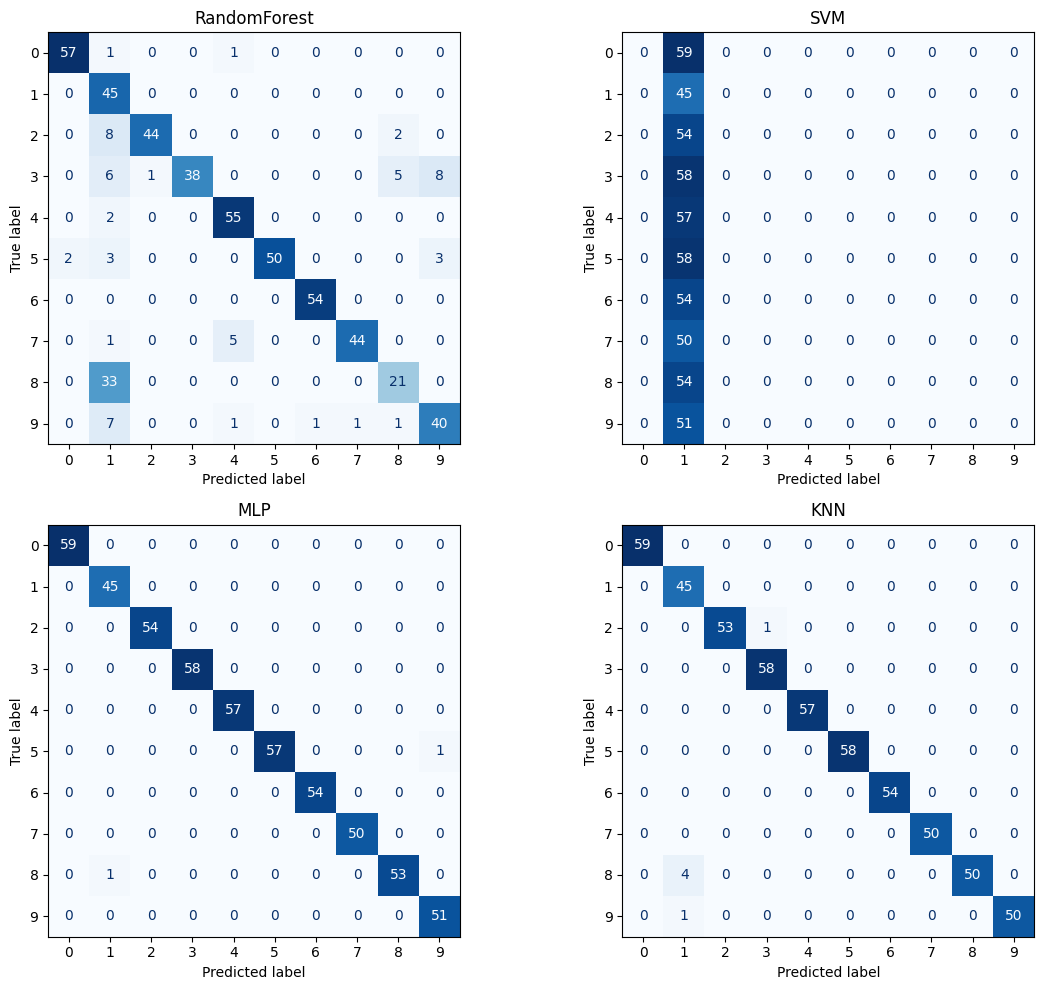

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

models = {"RandomForest": rf, "SVM": model, "MLP": mlp, "KNN": knn}

results = []
conf_matrices = {}

for name, m in models.items():
    # predictions (use existing train/test arrays)
    y_tr_pred = m.predict(X_train)
    y_te_pred = m.predict(X_test)

    acc = accuracy_score(y_test, y_te_pred)
    prec = precision_score(y_test, y_te_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_te_pred, average="weighted", zero_division=0)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec})
    conf_matrices[name] = confusion_matrix(y_test, y_te_pred)

# dataframe for easy display/plot
df_results = pd.DataFrame(results).set_index("model")
print(df_results)

# Plot comparison (grouped bar)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_results))
width = 0.25

ax.bar(x - width, df_results["accuracy"], width, label="Accuracy")
ax.bar(x, df_results["precision"], width, label="Precision")
ax.bar(x + width, df_results["recall"], width, label="Recall")

ax.set_xticks(x)
ax.set_xticklabels(df_results.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model comparison on test set")
ax.legend()
plt.tight_layout()
plt.show()

# Plot confusion matrices (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=digits.target_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

Predicted digit: 7


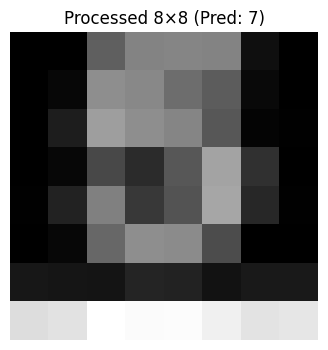

In [67]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# 1) Load, grayscale
orig = Image.open('images.jpeg')
img_gray = orig.convert('L')

# 2) Invert so digit = white, background = black (similar to digits dataset)
img_inv = ImageOps.invert(img_gray)

# 3) Threshold to get a mask of the digit
arr = np.array(img_inv)
mask = arr > 40  # tweak threshold

# 4) Find bounding box of the digit
coords = np.column_stack(np.where(mask))
ymin, xmin = coords.min(axis=0)
ymax, xmax = coords.max(axis=0) + 1
digit_crop = img_inv.crop((xmin, ymin, xmax, ymax))

# 5) Pad to square, then resize to 8x8
w, h = digit_crop.size
side = max(w, h)
square = Image.new('L', (side, side), 0)  # black background
square.paste(digit_crop, ((side - w) // 2, (side - h) // 2))
img_8x8 = square.resize((8, 8), Image.LANCZOS)

# 6) Scale to [0,16]
arr_8x8 = np.array(img_8x8).astype(np.float32)
arr_8x8 = (arr_8x8 / 255.0) * 16.0

img_flat = arr_8x8.flatten().reshape(1, -1)
img_flat_scaled = scaler.transform(img_flat)
pred =rf.predict(img_flat_scaled)
print("Predicted digit:", pred[0])

# visualize
plt.figure(figsize=(4,4))
plt.imshow(arr_8x8, cmap='gray', interpolation='nearest')
plt.title(f"Processed 8×8 (Pred: {pred[0]})")
plt.axis('off')
plt.show()
